# Content of this notebook
## 1 step - compare different models
| Модель | Тип | Backbone | Параметры |
|--------|-----|----------|-----------|
| YOLOv5n | One-stage (anchor-based) | CSPDarknet | ~1.9M |
| YOLOv8n | One-stage (anchor-free) | CSPDarknet-v8 | ~3.2M |
| YOLOv8s | One-stage (anchor-free) | CSPDarknet-v8 | ~11.2M |
| YOLOv8m | One-stage (anchor-free) | CSPDarknet-v8 | ~25.9M |
| YOLO11n | One-stage (anchor-free) | C3k2 + SPPF | ~2.6M |
| YOLO26n | One-stage (anchor-free) | YOLO26 backbone | ~2.4M |

## 2 step: Ablation study
- Learning rate: 1e-4, 1e-3, 1e-2
- Optimizer: SGD vs AdamW
- Batch size: 16, 64, 128
- Image size: 320, 640
- Augmentation: minimal vs full


## 1. Data Understanding & Dataset Composition

1.  **Roboflow Universe License Plate Recognition (version 12):** This dataset was initially provided and used for the architectural comparison.
2.  **Kaggle License Plate Dataset:** A larger dataset downloaded from Kaggle Hub to enrich our training data.



In [32]:
!pip3 install roboflow

In [39]:
import sys
!{sys.executable} -m pip install kagglehub

In [33]:
from roboflow import Roboflow
import yaml
from pathlib import Path

rf = Roboflow(api_key="...")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(1)
dataset = version.download("yolo26")

roboflow_dataset_root = Path("/content/License-Plate-Recognition-1")
roboflow_data_yaml_path = roboflow_dataset_root / "data.yaml"

with open(roboflow_data_yaml_path, 'r') as f:
    roboflow_data = yaml.safe_load(f)

roboflow_data['path'] = str(roboflow_dataset_root)
roboflow_data['train'] = str(roboflow_dataset_root / 'train' / 'images')
roboflow_data['val'] = str(roboflow_dataset_root / 'valid' / 'images')
if 'test' in roboflow_data:
    roboflow_data['test'] = str(roboflow_dataset_root / 'test' / 'images')

with open(roboflow_data_yaml_path, 'w') as f:
    yaml.dump(roboflow_data, f, sort_keys=False)

print(f"Modified Roboflow data.yaml at: {roboflow_data_yaml_path}")

loading Roboflow workspace...
loading Roboflow project...
Modified Roboflow data.yaml at: /content/License-Plate-Recognition-1/data.yaml


In [34]:
# !pip install ultralytics torchvision pandas matplotlib seaborn

import os
import json
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths — поменяй под свою машину
DATA_YAML = "/content/License-Plate-Recognition-1/data.yaml"  # путь к data.yaml
RESULTS_DIR = Path("/content/runs/results/comparison") # Corrected path for Ultralytics output
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: 0, CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [40]:
import kagglehub
import os

# Download latest version of the dataset
print("Downloading Kaggle dataset...")
kaggle_dataset_path = kagglehub.dataset_download("fareselmenshawii/license-plate-dataset")

print(f"Path to downloaded Kaggle dataset files: {kaggle_dataset_path}")

# Inspect the downloaded directory structure to confirm image/label paths
print("\nInspecting Kaggle dataset structure:")
for root, dirs, files in os.walk(kaggle_dataset_path):
    level = root.replace(str(kaggle_dataset_path), '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]: # print first 3 files in each directory
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...')
    if level > 2: # Limit depth to avoid overwhelming output
        break

Using Colab cache for faster access to the 'license-plate-dataset' dataset.
Path to downloaded Kaggle dataset files: /kaggle/input/license-plate-dataset

Inspecting Kaggle dataset structure:
license-plate-dataset/
    labels/
        val/
            790e3002a96d85a5.txt
            688f112cf2794184.txt
            ab2cff14a7b52e36.txt
            ...
        train/
            8f800311a45698f8.txt
            5d8aac464bd14445.txt
            c409373c5b2dc796.txt
            ...
    images/
        val/
            29d4a1543ff5d6c0.jpg
            4682945107ea5a0c.jpg
            df2ef3d26423a1fc.jpg
            ...
        train/
            def60dd03c549a25.jpg
            8d83f4730a92a89e.jpg
            3592ef943894df86.jpg
            ...


In [41]:
import os
import yaml
from pathlib import Path

# Original dataset paths
original_data_root = "/content/License-Plate-Recognition-1"
original_train_images = os.path.join(original_data_root, "train/images")
original_train_labels = os.path.join(original_data_root, "train/labels")
original_val_images = os.path.join(original_data_root, "valid/images")
original_val_labels = os.path.join(original_data_root, "valid/labels")

# Assuming the Kaggle dataset unpacks to a structure similar to YOLO datasets
# You might need to adjust these paths based on the actual inspection output from the previous cell
kaggle_train_images = os.path.join(str(kaggle_dataset_path), "train/images")
kaggle_train_labels = os.path.join(str(kaggle_dataset_path), "train/labels")
kaggle_val_images = os.path.join(str(kaggle_dataset_path), "valid/images")
kaggle_val_labels = os.path.join(str(kaggle_dataset_path), "valid/labels")

# Define the content for the new combined data.yaml
combined_data_yaml_content = {
    'path': '/content/combined_datasets_root', # A logical root for combined dataset paths
    'train': [
        original_train_images,
        kaggle_train_images
    ],
    'val': [
        original_val_images,
        kaggle_val_images
    ],
    'nc': 1,
    'names': ['license_plate']
}

# Create a directory for the new data.yaml if it doesn't exist
combined_yaml_dir = Path("/content/combined_data_config")
combined_yaml_dir.mkdir(parents=True, exist_ok=True)

# Path for the new combined data.yaml
new_data_yaml_path = combined_yaml_dir / "combined_data.yaml"

# Write the combined data to the new YAML file
with open(new_data_yaml_path, 'w') as f:
    yaml.dump(combined_data_yaml_content, f, sort_keys=False)

print(f"New combined data.yaml created at: {new_data_yaml_path}")

# Update DATA_YAML to point to the new combined file
DATA_YAML = str(new_data_yaml_path)
print(f"DATA_YAML has been updated to: {DATA_YAML}")

# Ensure the variable is globally accessible for subsequent cells
# (though in Colab, defining it once at module level is usually enough)


New combined data.yaml created at: /content/combined_data_config/combined_data.yaml
DATA_YAML has been updated to: /content/combined_data_config/combined_data.yaml


---
## Часть 1: Сравнение архитектур

### 1.1 Обучение YOLO моделей (Ultralytics)

In [38]:
!pip3 install ultralytics

In [42]:
import os
import torch
from pathlib import Path

DATA_YAML = "/content/combined_data_config/combined_data.yaml"
RESULTS_DIR = Path("/content/runs/results/comparison")
DEVICE = 0 if torch.cuda.is_available() else "cpu"

from ultralytics import YOLO

COMMON_ARGS = dict(
    data=DATA_YAML,
    epochs=10,
    imgsz=240,
    batch=32,
    optimizer="AdamW",
    cos_lr=True,
    patience=5,
    device=DEVICE,
    amp=True,
    workers=8,
    cache=True,
    flipud=0.0,
    close_mosaic=10,
    seed=42,
)

YOLO_MODELS = {
    "YOLOv5n":  "yolov5nu.pt",
    "YOLOv8n":  "yolov8n.pt",
    "YOLOv8s":  "yolov8s.pt",
    "YOLOv8m":  "yolov8m.pt",
    "YOLO11n":  "yolo11n.pt",
    "YOLO26n":  "yolo26n.pt",
}

global YOLO_MODELS

In [43]:
yolo_results = {}

for name, weights in YOLO_MODELS.items():
    print(f"\n{'='*60}")
    print(f"Training {name} ({weights})")
    print(f"{'='*60}")

    project_dir = str(RESULTS_DIR / "yolo_runs")
    run_name = name.lower()

    results_csv = Path(project_dir) / run_name / "results.csv"
    if results_csv.exists():
        print(f"  -> Already trained, skipping. Results at {results_csv}")
        continue

    model = YOLO(weights)
    t0 = time.time()
    results = model.train(
        **COMMON_ARGS,
        project=project_dir,
        name=run_name,
    )
    train_time = time.time() - t0

    yolo_results[name] = {
        "train_time_s": train_time,
        "weights_path": str(Path(project_dir) / run_name / "weights" / "best.pt"),
    }
    print(f"  -> Done in {train_time:.0f}s")
    torch.cuda.empty_cache()


Training YOLOv5n (yolov5nu.pt)
  -> Already trained, skipping. Results at /content/runs/results/comparison/yolo_runs/yolov5n/results.csv

Training YOLOv8n (yolov8n.pt)
  -> Already trained, skipping. Results at /content/runs/results/comparison/yolo_runs/yolov8n/results.csv

Training YOLOv8s (yolov8s.pt)
  -> Already trained, skipping. Results at /content/runs/results/comparison/yolo_runs/yolov8s/results.csv

Training YOLOv8m (yolov8m.pt)
  -> Already trained, skipping. Results at /content/runs/results/comparison/yolo_runs/yolov8m/results.csv

Training YOLO11n (yolo11n.pt)
New https://pypi.org/project/ultralytics/8.4.42 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=Non

### 1.4 Валидация всех YOLO моделей

In [44]:
import pandas as pd
import time
import torch
from pathlib import Path
from ultralytics import YOLO

all_metrics = []
df_arch = pd.DataFrame()

for name, weights in YOLO_MODELS.items():
    run_dir = RESULTS_DIR / "yolo_runs" / name.lower()
    best_pt = run_dir / "weights" / "best.pt"
    results_csv_path = run_dir / "results.csv"

    model_metrics = {"model": name, "type": "One-stage (YOLO)"}

    try:
        initial_model = YOLO(weights)
        n_params = sum(p.numel() for p in initial_model.model.parameters()) / 1e6
        model_metrics["params_M"] = round(n_params, 1)
    except Exception as e:
        print(f"Could not load initial model {weights} to count parameters: {e}")
        model_metrics["params_M"] = None

    if best_pt.exists():
        print(f"\nValidating {name} using best.pt...")
        model = YOLO(str(best_pt))

        t0 = time.time()
        results = model.val(data=DATA_YAML, batch=64, device=DEVICE, verbose=False)
        val_time = time.time() - t0

        model_metrics.update({
            "mAP50": round(results.box.map50, 4),
            "mAP50-95": round(results.box.map, 4),
            "precision": round(float(results.box.mp), 4),
            "recall": round(float(results.box.mr), 4),
            "inference_ms": round(results.speed["inference"], 2),
            "fps": round(1000 / max(results.speed["inference"], 0.01), 1),
        })
        all_metrics.append(model_metrics)

    elif results_csv_path.exists():
        print(f"\nLoading metrics for {name} from results.csv...")
        try:
            log = pd.read_csv(results_csv_path)
            log.columns = log.columns.str.strip()
            if not log.empty and "metrics/mAP50(B)" in log.columns:
                best_row = log.loc[log["metrics/mAP50(B)"].idxmax()]
                model_metrics.update({
                    "mAP50": round(best_row["metrics/mAP50(B)"], 4),
                    "mAP50-95": round(best_row["metrics/mAP50-95(B)"], 4),
                    "precision": round(best_row["metrics/precision(B)"], 4),
                    "recall": round(best_row["metrics/recall(B)"], 4),
                    "inference_ms": None,
                    "fps": None,
                })
                all_metrics.append(model_metrics)
            else:
                print(f"  -> results.csv for {name} is empty or missing required columns, skipping.")
        except Exception as e:
            print(f"  -> Error reading results.csv for {name}: {e}, skipping.")
    else:
        print(f"\nSkipping {name}: No best.pt weights or results.csv logs found at {run_dir}")

if all_metrics:
    df_arch = pd.DataFrame(all_metrics)
    df_arch = df_arch.sort_values("mAP50", ascending=False).reset_index(drop=True)
    print("\n" + "="*80)
    print("ARCHITECTURE COMPARISON (YOLO Models Only)")
    print("="*80)
    print(df_arch.to_string(index=False))

    df_arch.to_csv(RESULTS_DIR / "architecture_comparison.csv", index=False)
    df_arch.to_json(RESULTS_DIR / "architecture_comparison.json", orient="records", indent=2)
else:
    print("\nNo YOLO model metrics were collected. Cannot generate comparison table.")


Validating YOLOv5n using best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv5n summary (fused): 85 layers, 2,503,139 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 857.1±285.3 MB/s, size: 30.6 KB)
val: Scanning /content/License-Plate-Recognition-1/valid/labels.cache... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 536.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.3it/s 7.4s
                   all       2048       2134      0.972      0.902       0.94      0.628
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val

Validating YOLOv8n using best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 

### 1.5 Визуализация: сравнение архитектур

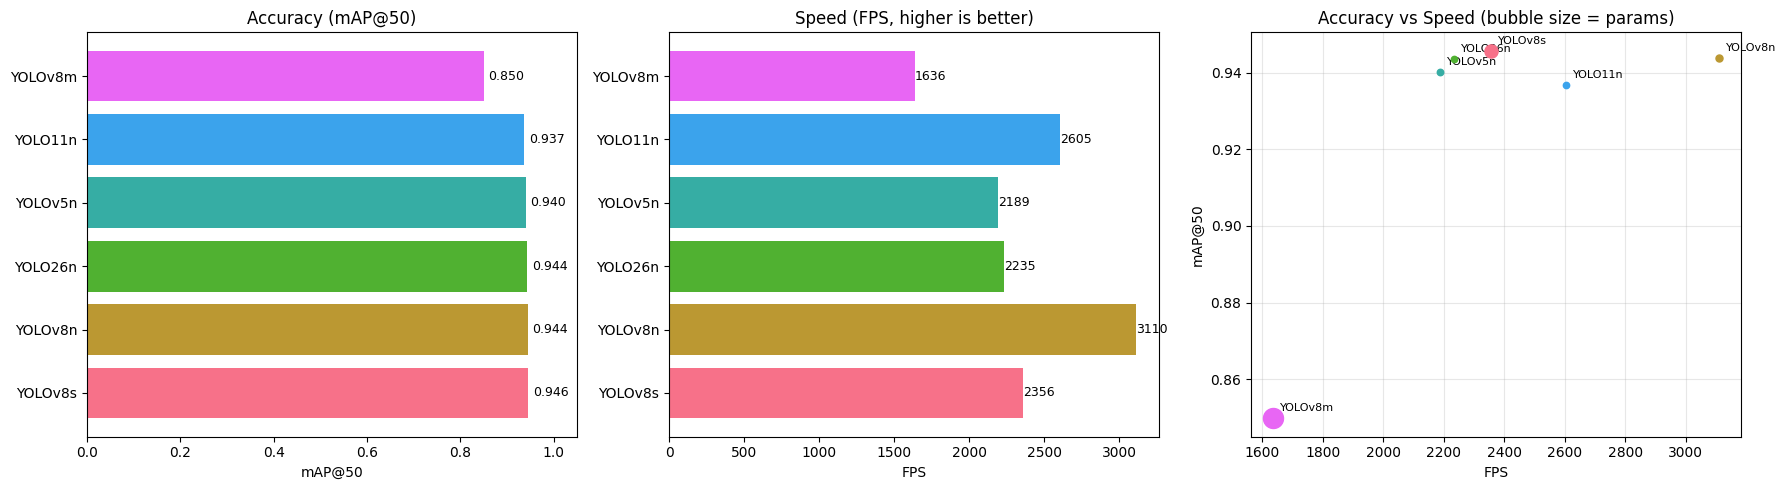

Saved to /content/runs/results/comparison/architecture_comparison.png


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not df_arch.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors = sns.color_palette("husl", len(df_arch))

    # 1. mAP50 bar chart
    ax = axes[0]
    bars = ax.barh(df_arch["model"], df_arch["mAP50"], color=colors)
    ax.set_xlabel("mAP@50")
    ax.set_title("Accuracy (mAP@50)")
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, df_arch["mAP50"]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
                va="center", fontsize=9)

    # 2. FPS bar chart
    ax = axes[1]
    bars = ax.barh(df_arch["model"], df_arch["fps"], color=colors)
    ax.set_xlabel("FPS")
    ax.set_title("Speed (FPS, higher is better)")
    for bar, val in zip(bars, df_arch["fps"]):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.0f}",
                va="center", fontsize=9)

    # 3. Accuracy vs Speed scatter
    ax = axes[2]
    for i, row in df_arch.iterrows():
        ax.scatter(row["fps"], row["mAP50"], color=colors[i], s=row["params_M"] * 8, zorder=5)
        ax.annotate(row["model"], (row["fps"], row["mAP50"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("FPS")
    ax.set_ylabel("mAP@50")
    ax.set_title("Accuracy vs Speed (bubble size = params)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "architecture_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {RESULTS_DIR / 'architecture_comparison.png'}")
else:
    print("df_arch is empty, skipping architecture comparison visualization.")

---
## Часть 2: Ablation Study — гиперпараметры

Используем YOLO26n как базовую модель и меняем по одному гиперпараметру за раз.

In [46]:

BASELINE = dict(
    model="yolov26n.pt",
    data=DATA_YAML,
    epochs=30,
    imgsz=320,
    batch=32,
    optimizer="AdamW",
    lr0=0.01,
    cos_lr=True,
    patience=5,
    device=DEVICE,
    amp=True,
    workers=2,
    cache=True,
    flipud=0.0,
    close_mosaic=10,
    seed=42,
)

ABLATION_EXPERIMENTS = {
    # ----- Learning Rate -----
    "lr_1e-4":     {"lr0": 1e-4},
    "lr_1e-3":     {"lr0": 1e-3},
    "lr_1e-2":     {"lr0": 1e-2},  # baseline
    "lr_5e-2":     {"lr0": 5e-2},

    # ----- Optimizer -----
    "opt_sgd":     {"optimizer": "SGD", "lr0": 0.01, "momentum": 0.937},
    "opt_adamw":   {"optimizer": "AdamW"},  # baseline
    "opt_adam":    {"optimizer": "Adam"},

    # ----- Batch Size -----
    "batch_16":    {"batch": 16},
    "batch_32":    {"batch": 32},   # New baseline
    "batch_64":    {"batch": 64},
}

In [ ]:
ablation_results = []

for exp_name, overrides in ABLATION_EXPERIMENTS.items():
    print(f"\n{'='*60}")
    print(f"Ablation: {exp_name} | overrides: {overrides}")
    print(f"{'='*60}")

    project_dir = str(RESULTS_DIR / "ablation_runs")

    results_csv = Path(project_dir) / exp_name / "results.csv"
    if results_csv.exists():
        print(f"  -> Already done, loading results...")
        log = pd.read_csv(results_csv)
        log.columns = log.columns.str.strip()
        best_row = log.loc[log["metrics/mAP50(B)"].idxmax()]
        ablation_results.append({
            "experiment": exp_name,
            **overrides,
            "best_epoch": int(best_row["epoch"]),
            "mAP50": round(best_row["metrics/mAP50(B)"], 4),
            "mAP50-95": round(best_row["metrics/mAP50-95(B)"], 4),
            "precision": round(best_row["metrics/precision(B)"], 4),
            "recall": round(best_row["metrics/recall(B)"], 4),
        })
        continue

    args = {**BASELINE, **overrides}
    model_weights = "yolov26n.pt"

    model = YOLO(model_weights)
    t0 = time.time()
    results = model.train(
        **args,
        project=project_dir,
        name=exp_name,
    )
    train_time = time.time() - t0

    # Read results
    log = pd.read_csv(results_csv)
    log.columns = log.columns.str.strip()
    best_row = log.loc[log["metrics/mAP50(B)"].idxmax()]

    ablation_results.append({
        "experiment": exp_name,
        **overrides,
        "best_epoch": int(best_row["epoch"]),
        "mAP50": round(best_row["metrics/mAP50(B)"], 4),
        "mAP50-95": round(best_row["metrics/mAP50-95(B)"], 4),
        "precision": round(best_row["metrics/precision(B)"], 4),
        "recall": round(best_row["metrics/recall(B)"], 4),
        "train_time_s": round(train_time, 0),
    })
    print(f"  -> mAP50={ablation_results[-1]['mAP50']:.4f} in {train_time:.0f}s")

df_ablation = pd.DataFrame(ablation_results)
print("\n" + "="*80)
print("ABLATION RESULTS")
print("="*80)
print(df_ablation[["experiment", "mAP50", "mAP50-95", "precision", "recall", "best_epoch"]].to_string(index=False))

df_ablation.to_csv(RESULTS_DIR / "ablation_results.csv", index=False)



Ablation: lr_1e-4 | overrides: {'lr0': 0.0001}
New https://pypi.org/project/ultralytics/8.4.42 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/License-Plate-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t